# Applied Deep Learning Final Project

The following notebook is used to fine-tune the BERT model (https://arxiv.org/abs/1810.04805) in order to create a fake news detector.

For this project, I fine-tuned BERT using the ISOT dataset.

## Importing Modules

In order to import the data in this project, clean it for training, import the BERT model and fine-tune it, I imported the following libraries.

In [1]:
# FROM: https://www.kaggle.com/code/aryand03/nlp-assignment
# Import required libraries for modifying and fine-tuning BERT model
import shutil
import os
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
import transformers
from transformers import AutoModel, BertTokenizerFast
from datasets import load_dataset, Dataset

### Clear previous fine-tuned BERT model

In order to ensure that each run will be independent of previous runs, this deletes the results directory, which contains the models' checkpoints.

In [2]:
# FROM Claude Code
# Clear stale checkpoints before each run. Old transformers versions (v4) saved
# LayerNorm params as gamma/beta; v5 expects weight/bias. Stale files cause a
# hard mismatch when load_best_model_at_end=True tries to reload the checkpoint.
for stale_dir in ("./results", "./logs"):
    if os.path.exists(stale_dir):
        shutil.rmtree(stale_dir)

## Data processing

In order to fine-tune the BERT model, I need to process the data in a way that is BERT native.

### ISOT Dataset

Link to dataset: https://www.kaggle.com/datasets/csmalarkodi/isot-fake-news-dataset

The ISOT dataset contains over 37,000 articles of true and fake news. It is used to fine-tune the BERT model in order to for it to be a good fake-news detector.

This dataset is broken into True.csv and Fake.csv, for true and fake news respectively. Each csv has the following columns:

- title: Title of a given article
- text: Article text
- subject: Article subject
- date: Article date

### Benefits to using the ISOT dataset

There is less fake news that real news, which would result in a skewed dataset. If one were to randomly sample from this set and train a model, the model would learn just to predict that every article is real news, instead of having to learn real news from fake news.

The ISOT dataset is a near 50/50 split between fake and real news. This means that the model will have to look for the differences between real and fake articles. 

### Data Cleaning

We removed the subject and date columns during this project. This is because the subject field might be a giveaway to the model and giveaway whether or not the article is True or Fake. The date field should have no relation on whether or not an article is True or Fake.

### BERT Native Changes

Furthermore, the ISOT dataset provides both the Title and the Text in seperate columns. This means that it is easy to use a BERT native seperator token (\[SEP\]) between the columns. BERT was pre-trained using the seperator tokens in order to weigh the importance of the title differently than that of the text.

### Training, Validation, and Testing

In order to create the sets used for training, validation, and testing, we will use the train_test_split twice in order to create these sets. Furthermore, we use the stratify_by_column parmaeter to ensure that there is an even spread of Fake and True entries between sets.


In [3]:
# FROM https://www.kaggle.com/code/aryand03/nlp-assignment
# Manipulate data to use datasets library - 
true_df = pd.read_csv("archive/True.csv")
fake_df = pd.read_csv("archive/Fake.csv")

# Add labels: 1 = True, 0 = Fake
true_df['label'] = 1
fake_df['label'] = 0

# Combine
df = pd.concat([true_df, fake_df], ignore_index=True)
df = df.sample(frac=1, random_state=42).reset_index(drop=True)  # shuffle

# # combine title and text into one single field.
# df['combined_text'] = df['title'] + " " + df['text']

# Only include the title, text, and label columns in final dataframe
df = df[['title','text', 'label']]

In [4]:
# FROM - https://huggingface.co/docs/datasets/use_with_pandas
# Convert from pandas to Dataset 
ds = Dataset.from_pandas(df)

# Convert the integer column to a ClassLabel
ds = ds.class_encode_column("label")

# First split: 80% Train, 20% "Remainder" (Val + Test)
train_remainder_split = ds.train_test_split(test_size=0.2, seed=42, stratify_by_column="label")

# Second split: Split that 20% remainder into half (10% Val, 10% Test)
test_val_split = train_remainder_split['test'].train_test_split(test_size=0.5, seed=42, stratify_by_column="label")

# Combine into a single DatasetDict
from datasets import DatasetDict

split_dataset = DatasetDict({
    'train': train_remainder_split['train'],
    'test': test_val_split['test'],
    'validation': test_val_split['train']
})

print(split_dataset)

Stringifying the column:   0%|          | 0/44898 [00:00<?, ? examples/s]

Casting to class labels:   0%|          | 0/44898 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['title', 'text', 'label'],
        num_rows: 35918
    })
    test: Dataset({
        features: ['title', 'text', 'label'],
        num_rows: 4490
    })
    validation: Dataset({
        features: ['title', 'text', 'label'],
        num_rows: 4490
    })
})


## Tokenize datasets

In order to get the dataset in a BERT native format, we need to tokenize the datasets. This is acheived using the Autotokenizer form the bert-base-uncased. 

We use uncased since there may be inconsistent capitalization between True and Fake news articles, which it would be safer to ignore that difference.

Furthermore, the title and text columns are tokenized as different sections, which BERT can distinguish between the two.

Furthermore, the tokenizer uses a padding of max_length so that any article shorter than the max length will have padding tokens to fit the max size in a batch.

For any article large than the limit, the model will cut off the rest in order to prevent Out of Memory Errors on my RTX 4070.

The max_length is set to 256 to balance VRAM usage on RTX 4070

In [5]:
# FROM - https://medium.com/@heyamit10/fine-tuning-bert-for-classification-a-practical-guide-b8c1c56f252c
# BERT Tokenization
from transformers import AutoTokenizer

# Initialize the BERT tokenizer
tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")

# Tokenize function, splits data into the title and text in a BERT native way
def tokenize_function(examples):
    return tokenizer(
        examples["title"], 
        examples["text"], 
        padding="max_length", 
        truncation=True, 
        max_length=256
    )

# Apply the tokenizer to the dataset
tokenized_datasets = split_dataset.map(tokenize_function, batched=True)

# Inspect tokenized samples
print(tokenized_datasets["train"][0])

Map:   0%|          | 0/35918 [00:00<?, ? examples/s]

Map:   0%|          | 0/4490 [00:00<?, ? examples/s]

Map:   0%|          | 0/4490 [00:00<?, ? examples/s]

{'title': '‘YOU’RE A SEXIST PIG!’ FEMINIST BATTLES Tucker Carlson over IvankaGate [Video]', 'text': 'https://www.youtube.com/watch?v=YeDU6dCR9tA', 'label': 0, 'input_ids': [101, 1520, 2017, 1521, 2128, 1037, 3348, 2923, 10369, 999, 1521, 10469, 7465, 9802, 22226, 2058, 7332, 2912, 5867, 1031, 2678, 1033, 102, 16770, 1024, 1013, 1013, 7479, 1012, 7858, 1012, 4012, 1013, 3422, 1029, 1058, 1027, 6300, 8566, 2575, 16409, 2099, 2683, 2696, 102, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0

## Model selection.

For this project, I chose the bert-base-uncased in order to stick to remote the potential connections between capitalization and the prediction. 

I use the id2label and label2id in order to map between 0 and 1 and Fake and True.

In [6]:
# FROM - https://medium.com/@heyamit10/fine-tuning-bert-for-classification-a-practical-guide-b8c1c56f252c
# Model selection

from transformers import AutoModelForSequenceClassification

# FROM - https://huggingface.co/docs/transformers/en/tasks/sequence_classification
# Create a map expected ids to their labels with id2label and label2id

id2label = {0: "FAKE", 1: "TRUE"}
label2id = {"FAKE": 0, "TRUE": 1}

# Initialize a BERT model for binary classification
model_name = "bert-base-uncased"
model = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=2, id2label=id2label, label2id=label2id)

print(model.config)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


BertConfig {
  "add_cross_attention": false,
  "architectures": [
    "BertForMaskedLM"
  ],
  "attention_probs_dropout_prob": 0.1,
  "bos_token_id": null,
  "classifier_dropout": null,
  "dtype": "float32",
  "eos_token_id": null,
  "gradient_checkpointing": false,
  "hidden_act": "gelu",
  "hidden_dropout_prob": 0.1,
  "hidden_size": 768,
  "id2label": {
    "0": "FAKE",
    "1": "TRUE"
  },
  "initializer_range": 0.02,
  "intermediate_size": 3072,
  "is_decoder": false,
  "label2id": {
    "FAKE": 0,
    "TRUE": 1
  },
  "layer_norm_eps": 1e-12,
  "max_position_embeddings": 512,
  "model_type": "bert",
  "num_attention_heads": 12,
  "num_hidden_layers": 12,
  "pad_token_id": 0,
  "position_embedding_type": "absolute",
  "tie_word_embeddings": true,
  "transformers_version": "5.5.4",
  "type_vocab_size": 2,
  "use_cache": true,
  "vocab_size": 30522
}



## Model Layer Freezing

For the project, I froze all of the layers except for the classifier, since there is no reason to use modify how BERT creates the contextual embeddings, we just need the model to be able to take these embeddings and fine-tune to identify whether or not the articles are True or Fake.

We can see that there is only 1538 trainable parameters

In [7]:
# FROM - https://medium.com/@heyamit10/fine-tuning-bert-for-classification-a-practical-guide-b8c1c56f252c
# Freeze layers

# Freeze all layers except the classifier
for param in model.bert.parameters():
    param.requires_grad = False

# Keep only the classification head trainable
for param in model.classifier.parameters():
    param.requires_grad = True

print(f"Trainable parameters: {sum(p.numel() for p in model.parameters() if p.requires_grad)}")

Trainable parameters: 1538


## Training Parameters.

Some parameters to to take note of, the batch size per GPU is set to 16 for training and evaluation, since I am training on my own hardware and need to ensure that I am not using all of the my resources when training. 

I set the learning rate to a 5e-5, so that there is no overstepping.

The model is set to train over 20 epochs to ensure that the prediction is able to approach a high accuracy. 

The metric for training is f1, since this accounts for both recall and precision, which a balance between both is required for a model that detects fake news. This metric is set so that the higher the f1 score, the better the model.

Also, instead of using fp16 precision, I set it to use bp16, which is native to my GPU's architecture.

In [17]:
# FROM - training pipeline https://medium.com/@heyamit10/fine-tuning-bert-for-classification-a-practical-guide-b8c1c56f252c

from transformers import TrainingArguments

# Define training arguments
training_args = TrainingArguments(
    output_dir="./results",           # Directory for saving model checkpoints
    eval_strategy="epoch",     # Evaluate at the end of each epoch
    learning_rate=5e-5,              # Start with a small learning rate
    per_device_train_batch_size=16,  # Batch size per GPU
    per_device_eval_batch_size=16,
    num_train_epochs=20,              # Number of epochs
    weight_decay=0.01,               # Regularization
    save_total_limit=2,              # Limit checkpoints to save space
    load_best_model_at_end=True,     # Automatically load the best checkpoint
    metric_for_best_model="f1",      # Use F1 for checkpoint
    greater_is_better=True,          # Ensure that the higher the F1, the better the model
    #logging_dir="./logs",            # Directory for logs
    logging_steps=100,               # Log every 100 steps
    bf16=True,                        # Chose bf16 over fp16 due to use Brain Floating Point since it is supported by my GPU and is more stable for BERT
    save_strategy="best"
)

print(training_args)

TrainingArguments(
accelerator_config={'split_batches': False, 'dispatch_batches': None, 'even_batches': True, 'use_seedable_sampler': True, 'non_blocking': False, 'gradient_accumulation_kwargs': None, 'use_configured_state': False},
adam_beta1=0.9,
adam_beta2=0.999,
adam_epsilon=1e-08,
auto_find_batch_size=False,
average_tokens_across_devices=True,
batch_eval_metrics=False,
bf16=True,
bf16_full_eval=False,
data_seed=None,
dataloader_drop_last=False,
dataloader_num_workers=0,
dataloader_persistent_workers=False,
dataloader_pin_memory=True,
dataloader_prefetch_factor=None,
ddp_backend=None,
ddp_broadcast_buffers=None,
ddp_bucket_cap_mb=None,
ddp_find_unused_parameters=None,
ddp_timeout=1800,
debug=[],
deepspeed=None,
disable_tqdm=False,
do_eval=True,
do_predict=False,
do_train=False,
enable_jit_checkpoint=False,
eval_accumulation_steps=None,
eval_delay=0,
eval_do_concat_batches=True,
eval_on_start=False,
eval_steps=None,
eval_strategy=IntervalStrategy.EPOCH,
eval_use_gather_object=False

## Compute metrics

The compute_metrics function computes both the f1 and accuracy score of the model when evaluating.

In [9]:
# FROM - https://medium.com/@heyamit10/fine-tuning-bert-for-classification-a-practical-guide-b8c1c56f252c
# Define a custom metric
from transformers import Trainer
from evaluate import load

# Load a metric (F1-score in this case)
metric_f1 = load("f1")
metric_acc = load("accuracy")
# Define a custom compute_metrics function
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = logits.argmax(axis=-1)
    # From Claude's code analysis, I will need to change the computer to use an average of "weighted"
    # This will account for class imbalance by weighting each class's F1 by how many samples it has.
    # This gives a single stable number instead of the wild swings given by binary F1 (only measuring for class 1)
    # return metric.compute(predictions=predictions, references=labels, average="weighted")
    # f1 = metric.compute(predictions=predictions, references=labels, average="weighted")["f1"]
    # acc = metric_acc.compute(predictions=predictions, references=labels)["accuracy"]
    
    # return {"f1": f1, "accuracy": acc}

    f1  = metric_f1.compute(predictions=predictions, references=labels, average="weighted")
    acc = metric_acc.compute(predictions=predictions, references=labels)
    # Merge both dicts so the Trainer logs eval_f1 and eval_accuracy each epoch
    return {**f1, **acc}



In [10]:
# FROM - https://medium.com/@heyamit10/fine-tuning-bert-for-classification-a-practical-guide-b8c1c56f252c
# Data collation
from transformers import DataCollatorWithPadding

# Ensures that padding is always set to the largest article in a batch instead of 256, which can save time and space.
data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

## Training

In [11]:
# FROM - https://medium.com/@heyamit10/fine-tuning-bert-for-classification-a-practical-guide-b8c1c56f252c
# Setup for Trainer
trainer = Trainer(
    model=model,                        # Pre-trained BERT model
    args=training_args,                 # Training arguments
    train_dataset=tokenized_datasets["train"],
    eval_dataset=tokenized_datasets["test"],
    processing_class=tokenizer,
    data_collator=data_collator,        # Efficient batching
    compute_metrics=compute_metrics     # Custom metric
)

# Start training
trainer.train()

Epoch,Training Loss,Validation Loss,F1,Accuracy
1,0.673336,0.668013,0.389749,0.536303
2,0.663825,0.650779,0.885258,0.885523
3,0.651578,0.636252,0.777929,0.789087
4,0.638401,0.624404,0.893134,0.893096
5,0.630251,0.616017,0.826640,0.829399
6,0.624018,0.604280,0.880076,0.881514
7,0.613947,0.596805,0.848711,0.852339
8,0.607992,0.593993,0.846605,0.848330
9,0.607161,0.586048,0.769420,0.781960
10,0.606037,0.579055,0.905697,0.906236


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La

TrainOutput(global_step=44900, training_loss=0.618646875819013, metrics={'train_runtime': 1246.2337, 'train_samples_per_second': 576.425, 'train_steps_per_second': 36.029, 'total_flos': 9.45042288642048e+16, 'train_loss': 0.618646875819013, 'epoch': 20.0})

## F1 and Accuracy overtime

The following code shows the Accuracy and F1 score of the validation set over each training epoch. This shows us that after training on 14 epochs, the model's performance stagnates.

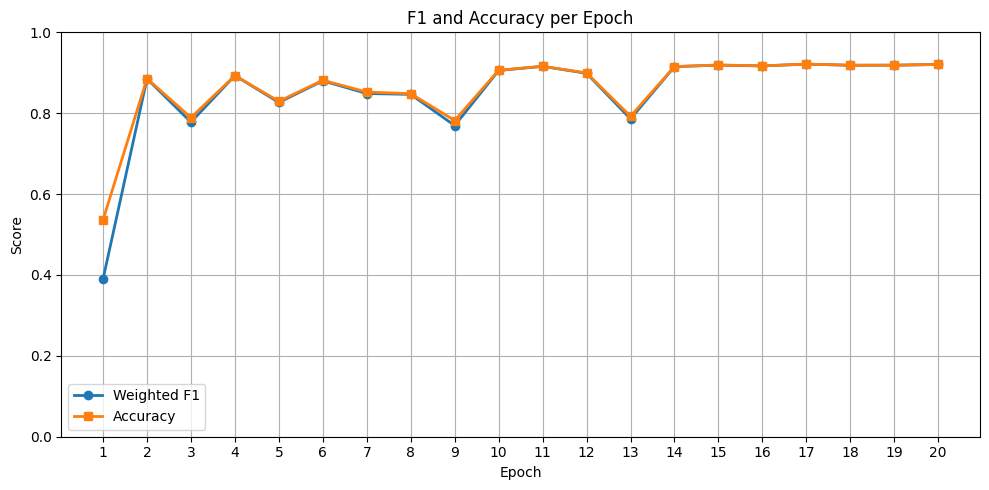

In [12]:
import matplotlib.pyplot as plt

# trainer.state.log_history is a flat list of dicts; eval entries are
# distinguished by having "eval_f1" present.
eval_logs = [e for e in trainer.state.log_history if "eval_f1" in e]

epochs    = [e["epoch"]    for e in eval_logs]
f1_scores = [e["eval_f1"]  for e in eval_logs]
acc_scores = [e["eval_accuracy"] for e in eval_logs]

fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(epochs, f1_scores,  marker="o", linewidth=2, label="Weighted F1")
ax.plot(epochs, acc_scores, marker="s", linewidth=2, label="Accuracy")

ax.set_xlabel("Epoch")
ax.set_ylabel("Score")
ax.set_title("F1 and Accuracy per Epoch")
ax.set_xticks(epochs)
ax.set_xticklabels([int(e) for e in epochs])
ax.set_ylim(0, 1)
ax.legend()
ax.grid(True)

fig.tight_layout()
fig.savefig("metrics_per_epoch.png", dpi=150)
plt.show()

In [13]:
# Prediction Analysis created using Claude Code
import torch
import torch.nn.functional as F

LABEL_NAMES = {0: "FAKE", 1: "REAL"}
CORRECT_MARKER = "✓"
WRONG_MARKER   = "✗"

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)
model.eval()

def predict(title: str, text: str) -> tuple[str, float]:
    """Return predicted label name and the confidence (probability) for it."""
    inputs = tokenizer(
        title,
        text,
        padding="max_length",
        truncation=True,
        max_length=256,
        return_tensors="pt",
    ).to(device)
    with torch.no_grad():
        logits = model(**inputs).logits          # shape: (1, 2)
    probs = F.softmax(logits, dim=-1)[0]         # convert raw scores → probabilities
    pred_idx = probs.argmax().item()
    return LABEL_NAMES[pred_idx], probs[pred_idx].item()


# Sample a fixed set: 5 correctly classified + 5 misclassified, for balance.
# We iterate the raw test split and collect examples until we have enough of each.
correct_samples, wrong_samples = [], []

for row in split_dataset["test"]:
    if len(correct_samples) >= 5 and len(wrong_samples) >= 5:
        break
    pred_label, confidence = predict(row["title"], row["text"])
    true_label = LABEL_NAMES[row["label"]]
    entry = {
        "title":      row["title"],
        "text":       row["text"][:300],   # truncate long articles for display
        "true_label": true_label,
        "pred_label": pred_label,
        "confidence": confidence,
        "correct":    pred_label == true_label,
    }
    if entry["correct"] and len(correct_samples) < 5:
        correct_samples.append(entry)
    elif not entry["correct"] and len(wrong_samples) < 5:
        wrong_samples.append(entry)

# Print a formatted qualitative report.
def print_sample(idx: int, entry: dict) -> None:
    marker = CORRECT_MARKER if entry["correct"] else WRONG_MARKER
    print(f"  [{marker}] Sample {idx + 1}")
    print(f"      Title      : {entry['title'][:120]}")
    print(f"      Text (clip): {entry['text'][:120]}...")
    print(f"      True label : {entry['true_label']}")
    print(f"      Predicted  : {entry['pred_label']}  (confidence: {entry['confidence']:.1%})")
    print()

print("\n" + "═" * 70)
print("  QUALITATIVE ANALYSIS — Sample Predictions")
print("═" * 70)

print("\n── Correctly Classified ─────────────────────────────────────────────\n")
for i, entry in enumerate(correct_samples):
    print_sample(i, entry)

print("── Misclassified ────────────────────────────────────────────────────\n")
for i, entry in enumerate(wrong_samples):
    print_sample(i, entry)

print("═" * 70)



══════════════════════════════════════════════════════════════════════
  QUALITATIVE ANALYSIS — Sample Predictions
══════════════════════════════════════════════════════════════════════

── Correctly Classified ─────────────────────────────────────────────

  [✓] Sample 1
      Title      :  Fresh Off The Golf Course, Trump Lashes Out At FBI Deputy Director And James Comey
      Text (clip): Donald Trump spent a good portion of his day at his golf club, marking the 84th day he s done so since taking the oath o...
      True label : FAKE
      Predicted  : FAKE  (confidence: 55.1%)

  [✓] Sample 2
      Title      : U.S. to continue supporting engagement with Cuban people: Kerry
      Text (clip): WASHINGTON (Reuters) - U.S. Secretary of State John Kerry offered his condolences to the Cuban people on Saturday, addin...
      True label : REAL
      Predicted  : REAL  (confidence: 61.7%)

  [✓] Sample 3
      Title      : THE VIDEO HILLARY CLINTON Does NOT Want You To See
      Text (cl

## Accuracy, F1 Score, and Confusion Matrix

We can see below that we have F1 Score of .9214, an Accuracy of .9214 and we can see that in the confusion matrix, that the model is more likely to predict Fake news as True than it is to predict True news as Fake.

  Final Test-Set Evaluation
  Weighted F1 : 0.9214
  Accuracy    : 0.9214


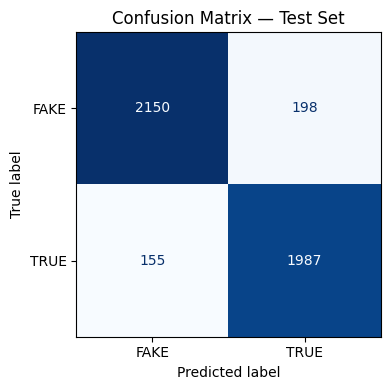

Confusion matrix saved to confusion_matrix.png


In [16]:
# The following is from Claude Code
# Final evaluation on the held-out test set                                                                                        
import numpy as np                                                                                                                 
import matplotlib.pyplot as plt                                                                                                    
from sklearn.metrics import (                                                                                                      
    f1_score,                                                                                                                      
    accuracy_score,                                                                                                                
    confusion_matrix,                                                                                                              
    ConfusionMatrixDisplay,                                                                                                        
)                                                                                                                                  
                                                                                                                                   
# Use the Trainer to get predictions on the test split                                                                             
test_output = trainer.predict(tokenized_datasets["test"])                                                                          
                                                                                                                                   
preds  = test_output.predictions.argmax(axis=-1)                                                                                   
labels = test_output.label_ids                                                                                                     
                                                                                                                                   
# ── Metrics ──────────────────────────────────────────────────────────────────                                                    
f1  = f1_score(labels, preds, average="weighted")                                                                                  
acc = accuracy_score(labels, preds)                                                                                                
                                                                                                                                   
print("=" * 45)                                                                                                                    
print("  Final Test-Set Evaluation")                                                                                               
print("=" * 45)                                                                                                                    
print(f"  Weighted F1 : {f1:.4f}")                                                                                                 
print(f"  Accuracy    : {acc:.4f}")                                                                                                
print("=" * 45)                                                                                                                    
                                                                                                                                   
# ── Confusion Matrix ──────────────────────────────────────────────────────────                                                   
class_names = ["FAKE", "TRUE"]                                                                                                     
cm = confusion_matrix(labels, preds)                                                                                               
                                                                                                                                   
fig, ax = plt.subplots(figsize=(5, 4))                                                                                             
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)                                                     
disp.plot(ax=ax, colorbar=False, cmap="Blues")                                                                                     
ax.set_title("Confusion Matrix — Test Set")                                                                                        
fig.tight_layout()                                                                                                                 
fig.savefig("confusion_matrix.png", dpi=150)                                                                                       
plt.show()                                                                                                                         
print("Confusion matrix saved to confusion_matrix.png")                                                                            
